# Predicting Medical Insurance Charges Project

Project Overview
This project will help you apply Python data analysis skills to a real-world healthcare dataset. You will perform data cleaning, exploratory data analysis, visualization, and regression modeling to understand the factors that influence medical insurance costs.

Dataset
Can be downloaded from Kaggle using the link https://www.kaggle.com/datasets/mirichoi0218/insurance.  Alternatively, I have attached the dataset

Project Learning Objectives
- Load and inspect real-world data using pandas
- Clean and prepare data for analysis
- Visualize relationships between variables
- Handle categorical variables using encoding
- Build simple and multiple linear regression models
- Evaluate model performance



## Part 1: Data Loading and Understanding



In [1]:
# Loading the necessary libraries
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load dataset
df = pd.read_csv("insurance.csv")

# Display first rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Shape of dataset
print("Shape:", df.shape)

# Data types
print(df.dtypes)

# Summary statistics
df.describe()

Shape: (1338, 7)
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## PART 2: Data Cleaning

In [5]:
# Check Missing Values
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

There are typically no missing values in this dataset.

In [6]:
# Check for duplicates
df.duplicated().sum()

np.int64(1)

In [7]:
# Remove duplicates if any
df = df.drop_duplicates()

## PART 3: Exploratory Data Analysis

### Histogram of charges

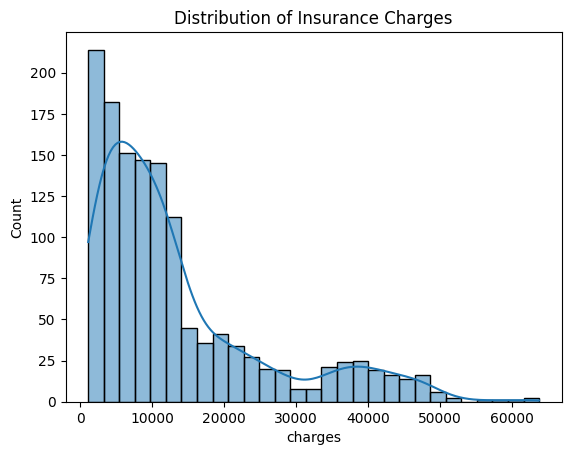

In [8]:
plt.figure()
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

Charges are right-skewed (few people pay very high costs).

### Boxplot: Charges by Smoker

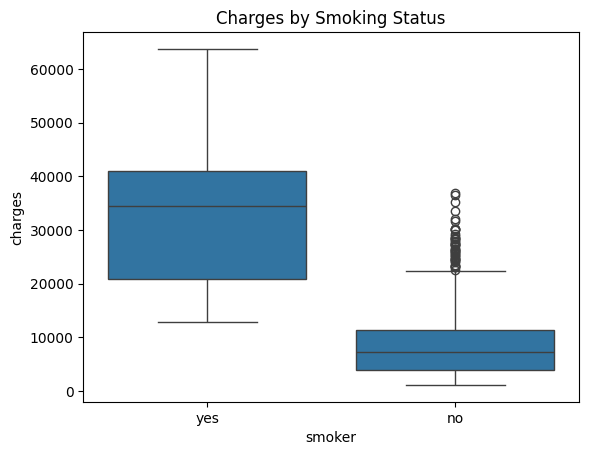

In [9]:
plt.figure()
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges by Smoking Status")
plt.show()

Smokers pay significantly higher insurance charges.

### Scatterplot: BMI vs Charges

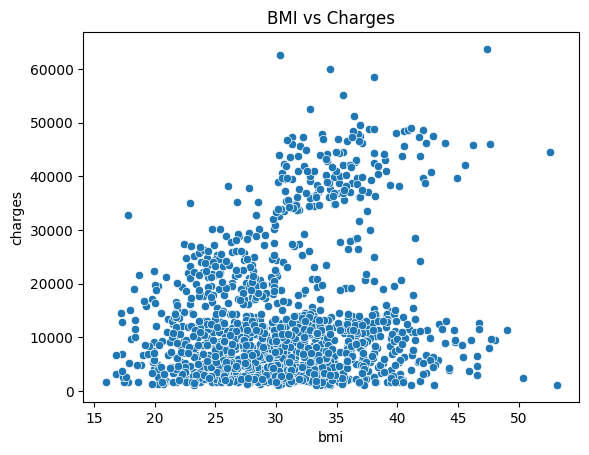

In [10]:
plt.figure()
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()

Higher BMI tends to be associated with higher charges.

### Barplot: Average Charges by Region

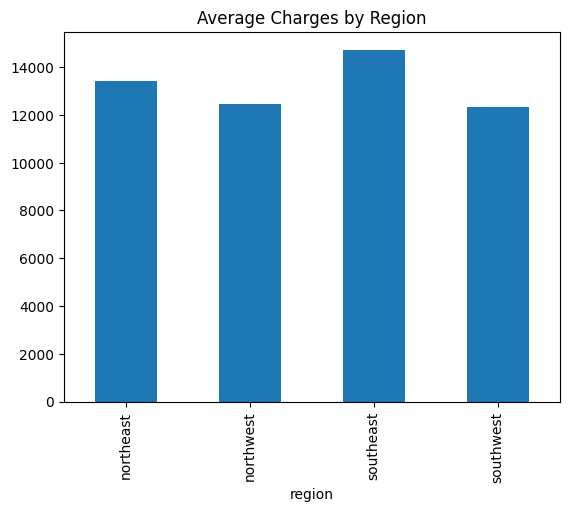

In [11]:
plt.figure()
df.groupby('region')['charges'].mean().plot(kind='bar')
plt.title("Average Charges by Region")
plt.show()

Regional differences exist but are smaller than smoking effect.

### Correlation Heatmap (Numerical Only)

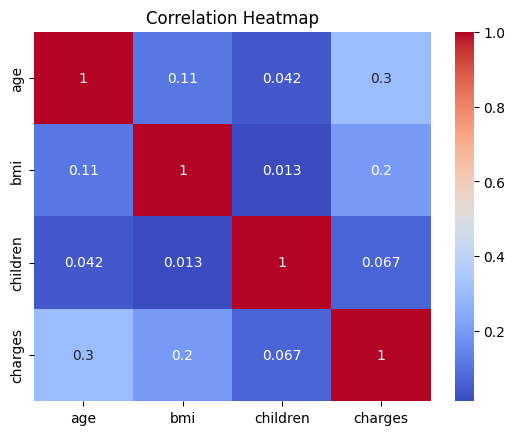

In [12]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## PART 4: Categorical Encoding

In [13]:
# Convert categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [14]:
# check new columns
print(df_encoded.columns)

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')


## PART 5: Simple Linear Regression

### Predict charges using BMI

In [15]:
# Define variables
X = df[['bmi']]
y = df['charges']

# Add constant
X = sm.add_constant(X)

# Fit model
model1 = sm.OLS(y, X).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     54.70
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           2.47e-13
Time:                        17:25:50   Log-Likelihood:                -14440.
No. Observations:                1337   AIC:                         2.888e+04
Df Residuals:                    1335   BIC:                         2.889e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1202.1404   1664.857      0.722      0.4

BMI coefficient is positive.

p-value < 0.05 → statistically significant.

R² is relatively low → BMI alone is not a strong predictor.

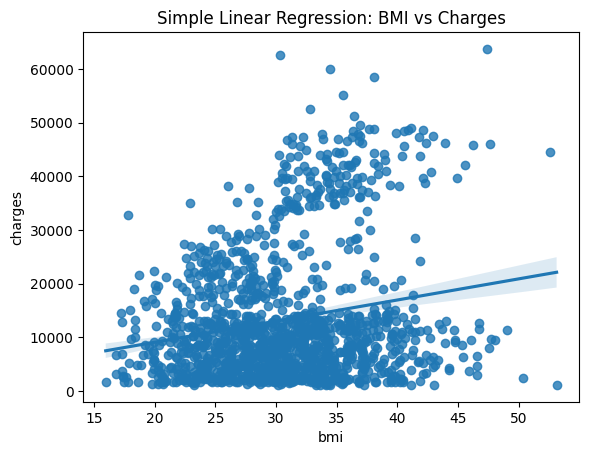

In [16]:
# Plot Regression Line
plt.figure()
sns.regplot(x='bmi', y='charges', data=df)
plt.title("Simple Linear Regression: BMI vs Charges")
plt.show()

## PART 6: Multiple Linear Regression


### Define Variables

In [19]:
# Features and target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# IMPORTANT FIX: convert all to float
X = X.astype(float)
y = y.astype(float)

# Add constant
X = sm.add_constant(X)

# Fit model
model2 = sm.OLS(y, X).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Tue, 24 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:34:28   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    988.227  

R² is much higher than simple regression.

Smoking status has the strongest positive effect.

Age and BMI are also significant predictors.

Multiple regression improves prediction accuracy.

Final Report Questions
Answer the following in a short report:
###### 1. Does smoking significantly increase insurance charges?
Yes. Smokers have much higher average charges than non-smokers. 
The regression model shows smoking is the strongest predictor of insurance costs.

###### 2. Which factor affects charges the most?
Smoking status has the largest effect, followed by age and BMI.

###### 3. Was multiple regression better than simple regression?
Yes. Multiple regression produced a higher R² and lower prediction error, meaning it explains insurance charges better.

###### 4. What limitations exist in your model?
Dataset is relatively small

Possible nonlinear relationships not explored

Outliers may influence results

Other health variables are not included


                                       # End of project. 